In [1]:
import numpy as np
import basis_func as bf
import matplotlib.pyplot as plt

In [2]:
def beam_element_stiffness_matrix(EI, h):
    """
    Returns the 4x4 element stiffness matrix for a Euler-Bernoulli beam element.

    Parameters:
    EI : float
        Flexural rigidity (Young's modulus * moment of inertia)
    h : float
        Length of the beam element

    Returns:
    Ke : (4, 4) numpy.ndarray
        Element stiffness matrix
    """
    factor = EI / h**3
    Ke = factor * np.array([
        [12,   6*h,  -12,   6*h],
        [6*h, 4*h**2, -6*h, 2*h**2],
        [-12, -6*h,   12,  -6*h],
        [6*h, 2*h**2, -6*h, 4*h**2]
    ])
    return Ke

def beam_element_mass_matrix(rho, h):
    factor = rho * h / 420
    return factor * np.array([
        [156,    22*h,    54,   -13*h],
        [22*h,   4*h**2,  13*h, -3*h**2],
        [54,     13*h,   156,   -22*h],
        [-13*h, -3*h**2, -22*h,  4*h**2]
    ])

def newmark_beta_timestep(
    u_cur: np.ndarray,
    v_cur: np.ndarray,
    a_cur: np.ndarray,
    M: np.ndarray,
    C: np.ndarray,
    K: np.ndarray,
    f_next: np.ndarray, # Force vector at the *next* time step (t + dt)
    dt: float,
    beta: float = 0.25,
    gamma: float = 0.5
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Performs a single time step integration using the Newmark-beta method.

    Args:
        u_cur (np.ndarray): Current displacement vector (u_t).
        v_cur (np.ndarray): Current velocity vector (v_t).
        a_cur (np.ndarray): Current acceleration vector (a_t).
        M (np.ndarray): Mass matrix.
        C (np.ndarray): Damping matrix.
        K (np.ndarray): Stiffness matrix.
        f_next (np.ndarray): Force vector at the next time step (f_{t+dt}).
        dt (float): Time step size.
        beta (float): Newmark-beta parameter, typically 0.25 for average acceleration.
        gamma (float): Newmark-beta parameter, typically 0.5 for average acceleration.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: 
            u_next (np.ndarray): Displacement vector at the next time step (u_{t+dt}).
            v_next (np.ndarray): Velocity vector at the next time step (v_{t+dt}).
            a_next (np.ndarray): Acceleration vector at the next time step (a_{t+dt}).
    """

    # Pre-calculate constants for efficiency
    c1 = 1 / (beta * dt**2)
    c2 = gamma / (beta * dt)
    c3 = 1 / (beta * dt)
    c4 = 1 / (2 * beta) - 1
    c5 = 1 - (gamma / beta)
    c6 = dt * (1 - (gamma / (2 * beta)))

    # Calculate the effective stiffness matrix (LHS)
    # [M]c1 + [C]c2 + [K]
    lhs = M * c1 + C * c2 + K

    # Calculate the effective force vector (RHS)
    # f_next + M @ (u_cur*c1 + v_cur*c3 + a_cur*c4) + C @ (u_cur*c2 + v_cur*c5 + a_cur*c6)
    rhs_M_term = M @ (u_cur * c1 + v_cur * c3 + a_cur * c4)
    rhs_C_term = C @ (u_cur * c2 + v_cur * c5 + a_cur * c6)
    rhs = f_next + rhs_M_term + rhs_C_term

    # Solve for the next displacement (u_{t+dt})
    u_next = np.linalg.solve(lhs, rhs)

    # Calculate the next acceleration (a_{t+dt})
    a_next = c1 * (u_next - u_cur) - c3 * v_cur - c4 * a_cur

    # Calculate the next velocity (v_{t+dt})
    v_next = c2 * (u_next - u_cur) + c5 * v_cur + c6 * a_cur

    return u_next, v_next, a_next

In [3]:
# FEM example for equally spaced elements for a cantilever beam with a (downwards) force at the end.
n = 9
L = 1
EI = 1.0
F = 10
h = L/n

FEM w_end:  -3.333333333330638
Analytical w_end:  -3.333333333333333


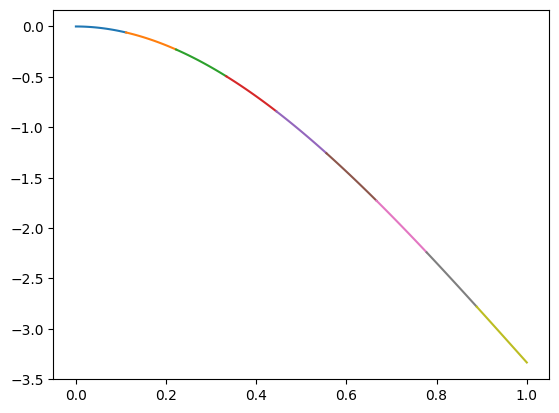

In [4]:
Ndof = 2 * (n + 1)
K = np.zeros((Ndof, Ndof))
f = np.zeros(Ndof)

for el in range(n):
    Ke = beam_element_stiffness_matrix(EI, h) # 4x4
    dof_map = [2*el, 2*el+1, 2*el+2, 2*el+3]
    for i in range(4):
        for j in range(4):
            K[dof_map[i], dof_map[j]] += Ke[i, j]

# Apply boundary conditions (fixed left end)
bc_dofs = [0, 1]
for dof in bc_dofs:
    K[dof, :] = 0
    K[:, dof] = 0
    K[dof, dof] = 1
    f[dof] = 0

# Apply load at free end (last node displacement DOF)
f[-2] = -F

sol = np.linalg.solve(K, f)

for el in range(n):
    x = np.linspace(el * h, (el + 1) * h, 100)
    w = bf.shape_function_interpolate(sol[2*el : 2*(el+2)], x[0], x[-1], x)
    plt.plot(x, w)

    if el + 1 == n:
        print("FEM w_end: ", w[-1])

print("Analytical w_end: ", 1/3 * -F * L**3 / EI)

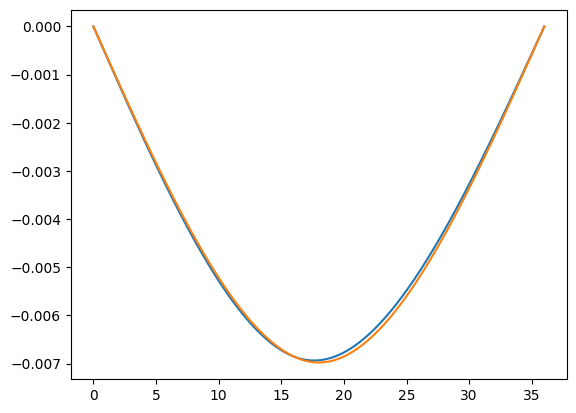

In [5]:
# FEM simply supported beam example, force applied at midspan

n = 15
L = 36
EI = 2.1e11 * 0.41
v = 27.78
h = L/n
dt = 0.0001
t_end = L/v
rho = 17000

Mc = 42.11e3
Mb = 68.20e2
Ma = 18.13e2
Mt = Mc + 2 * Mb + 4 * Ma
F = Mt * 9.81

Ndof = 2 * (n + 1)
K = np.zeros((Ndof, Ndof))
f = np.zeros(Ndof)

for el in range(n):
    Ke = beam_element_stiffness_matrix(EI, h) # 4x4
    dof_map = [2*el, 2*el+1, 2*el+2, 2*el+3]
    for i in range(4):
        for j in range(4):
            K[dof_map[i], dof_map[j]] += Ke[i, j]

# Apply boundary conditions (fixed left end)
bc_dofs = [0, 2*n]
for dof in bc_dofs:
    K[dof, :] = 0
    K[:, dof] = 0
    K[dof, dof] = 1
    f[dof] = 0

# Apply load at mid-span
mid_node = n // 2
mid_dof = 2 * mid_node
f[mid_dof] = -F

sol = np.linalg.solve(K, f)

num_x_per_element = 100
num_x_total = num_x_per_element * n

w_total_list = []
x_total_list = []

for el in range(n):
    x = np.linspace(el * h, (el + 1) * h, num_x_per_element, endpoint=True)
    w = bf.shape_function_interpolate(sol[2*el : 2*el + 4], x[0], x[-1], x)
    x_total_list.append(x)
    w_total_list.append(w)

x_total = np.concatenate(x_total_list)
w_total = np.concatenate(w_total_list)

plt.plot(x_total, w_total)

def analytical(x):
    w = np.zeros_like(x)
    for i, xi in enumerate(x):
        if xi <= L / 2:
            w[i] = -F * xi * (3*L**2 - 4*xi**2) / (48 * EI)
        else:
            w[i] = -F * (L - xi) * (3*L**2 - 4*(L - xi)**2) / (48 * EI)
    return w

x = np.linspace(0, L, num_x_total)
w_analytical = analytical(x)
plt.plot(x, w_analytical, label="Analytical deflection")


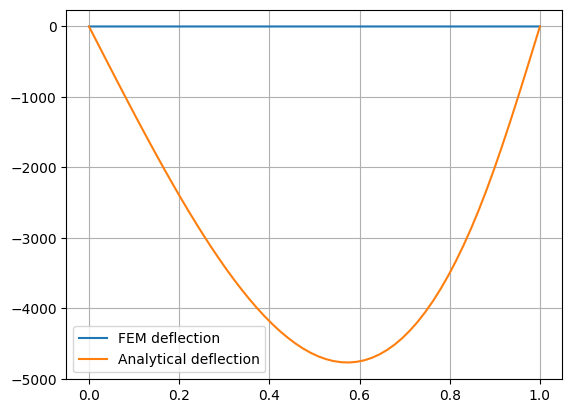

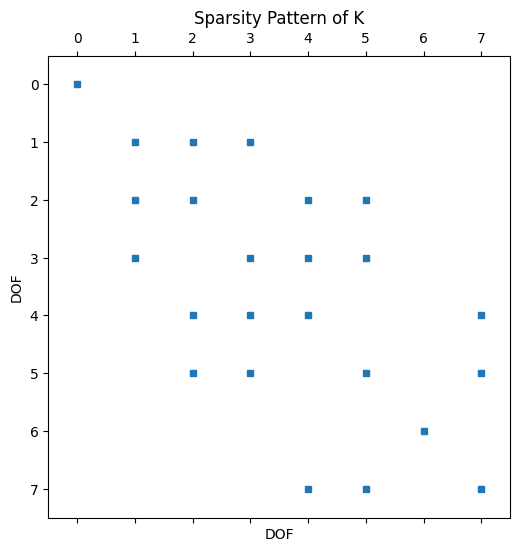

In [6]:
# FEM simply supported beam example, force applied at random location along the beam
n = 3
L = 1
EI = 1.0
F_val = 10
h = L/n
Fx = 0.877

Ndof = 2 * (n + 1)
K = np.zeros((Ndof, Ndof))
f = np.zeros(Ndof)

for el in range(n):
    Ke = beam_element_stiffness_matrix(EI, h) # 4x4
    dof_map = [2*el, 2*el+1, 2*el+2, 2*el+3]
    for i in range(4):
        for j in range(4):
            K[dof_map[i], dof_map[j]] += Ke[i, j]

element_idx_force = int(Fx // h)
if element_idx_force >= n: # If Fx == L
    element_idx_force = n - 1
    x_local_force = h # Local coordinate of force within that element
else:
    x_local_force = Fx - element_idx_force * h

# Apply load at Fx
N1f, N2f, N3f, N4f = bf.shape_function_values(x_local_force, h)
f_el = np.zeros(4)
f_el[0] = (-F_val) * N1f  # Vertical force at left node of element
f_el[1] = (-F_val) * N2f  # Moment at left node of element
f_el[2] = (-F_val) * N3f  # Vertical force at right node of element
f_el[3] = (-F_val) * N4f  # Moment at right node of element



# Add to global force vector
dof_map_force = [
    2 * element_idx_force,      # v_left
    2 * element_idx_force + 1,  # theta_left
    2 * element_idx_force + 2,  # v_right
    2 * element_idx_force + 3   # theta_right
]

for i in range(4):
    if dof_map_force[i] < Ndof: # Check to avoid index out of bounds (shouldn't happen with correct logic)
        f[dof_map_force[i]] += f_el[i]

# Apply boundary conditions (fixed left and right end)
bc_dofs = [0, 2*n]
for dof in bc_dofs:
    K[dof, :] = 0
    K[:, dof] = 0
    K[dof, dof] = 1
    f[dof] = 0

sol = np.linalg.solve(K, f)

num_x_per_element = 20
num_x_total = num_x_per_element * n

w_total_list = []
x_total_list = []

for el in range(n):
    x = np.linspace(el * h, (el + 1) * h, num_x_per_element, endpoint=True)
    w = bf.shape_function_interpolate(sol[2*el : 2*el + 4], x[0], x[-1], x)
    x_total_list.append(x)
    w_total_list.append(w)

x_total = np.concatenate(x_total_list)
w_total = np.concatenate(w_total_list)

plt.plot(x_total, w_total, label="FEM deflection")

def analytical(x):
    a = Fx
    b = L - a
    w = np.zeros_like(x)

    for i, xi in enumerate(x):
        if xi <= a:
            w[i] = -F * b * xi * (L**2 - b**2 - xi**2) / (6 * L * EI)
        else:
            w[i] = -F * a * (L - xi) * (2 * L * xi - xi**2 - a**2) / (6 * L * EI)
    return w


x = np.linspace(0, L, num_x_total)
w_analytical = analytical(x)
plt.plot(x, w_analytical, label="Analytical deflection")
plt.legend()
plt.grid()

plt.figure(figsize=(6, 6))
plt.spy(K, markersize=4)
plt.title('Sparsity Pattern of K')
plt.xlabel('DOF')
plt.ylabel('DOF')
plt.show()
